## __Data Science: Capstone Part 2: Lightning Talk 2__

## Problem Statement

Online learning platforms such as ASSISTments collect detailed information about student performance and learning behaviors. However, students have different learning needs, making it difficult for educators to provide personalized support.

This project aims to identify distinct student learning profiles based on performance, attempts, response time, hint usage, and practice behavior. These profiles will help educators better understand students' learning needs and provide targeted interventions, with the goal of improving student performance by 10%.

## Data Info
Data Source : https://sites.google.com/site/assistmentsdata/home/2009-2010-assistment-data/skill-builder-data-2009-2010

## Objectives
List the key questions guiding your analysis and modeling:
- What features influence the target variable?
- Can feature engineering improve model performance?
- How do different model versions compare?

## Data Dictionary

| Feature | Data Type | Description |
|---------|----------|-------------|
| **order_id** | Integer | Chronological identifier of the student's interaction. Larger values indicate later interactions. |
| **assignment_id** | Integer | Unique identifier of the assignment (homework or activity) created by a teacher for a class. Different teachers can assign the same content but have different assignment IDs. |
| **user_id** | Integer | Unique identifier for each student. |
| **assistment_id** | Integer | Identifier of the ASSISTment (tutoring activity). One ASSISTment may contain multiple related problems or scaffold questions. |
| **problem_id** | Integer | Unique identifier for an individual problem. |
| **original** | Binary (0/1) | Indicates whether the problem is the original question (`1`) or a scaffold/help question (`0`). |
| **correct** | Binary (0/1) | Indicates whether the student answered correctly on the first attempt (`1`) or answered incorrectly/requested help (`0`). This is commonly used as the target variable. |
| **attempt_count** | Integer | Number of attempts the student made before completing the problem. |
| **ms_first_response** | Integer | Time (in milliseconds) between displaying the problem and the student's first response. |
| **tutor_mode** | Categorical | Learning mode during the interaction. Possible values include `tutor`and `test` |
| **answer_type** | Categorical | Type of expected answer (e.g., `choose_1`, `algebra`, `fill_in`, `open_response`). |
| **sequence_id** | Integer | Identifier of the problem set. Multiple assignments can share the same sequence if they use the same problem set. |
| **student_class_id** | Integer | Identifier of the student's classroom or class section. |
| **position** | Integer | Position of the assignment on the student's assignment page. |
| **problem_set_type** | Categorical | Organization of the problem set. Possible values include `Linear`, `Random`, and `Mastery`. |
| **base_sequence_id** | Integer | Identifier of the original sequence from which the current sequence was copied. If not copied, it is equal to `sequence_id`. |
| **skill_id** | Integer | Identifier of the mathematical skill associated with the problem. In the Skill Builder dataset, each row contains only one skill. Multi-skill problems are duplicated into multiple rows. |
| **skill_name** | String | Name of the mathematical skill associated with the problem. |
| **teacher_id** | Integer | Unique identifier of the teacher who assigned the problem. |
| **school_id** | Integer | Unique identifier of the school. |
| **hint_count** | Integer | Number of hints requested by the student while solving the problem. |
| **hint_total** | Integer | Total number of hints available for the problem. |
| **overlap_time** | Integer | Time (in milliseconds) representing overlapping student activity while interacting with the problem. |
| **template_id** | Integer | Identifier of the ASSISTment template. Problems sharing the same template have similar structures but different values. |
| **answer_id** | Integer | Identifier of the selected answer for multiple-choice questions. |
| **answer_text** | String | Student's submitted answer for fill-in or text-based questions. |
| **first_action** | Categorical | Student's first action after viewing the problem, such as `attempt` or `hint`. |
| **bottom_hint** | Binary (0/1) | Indicates whether the student requested the bottom-out hint (the final hint revealing the solution). |
| **opportunity** | Integer | Number of previous opportunities the student has had to practice the associated skill. |
| **opportunity_original** | Integer | Number of previous opportunities the student has had to practice the skill considering only original problems (`original = 1`). |
| **correct** | Binary (0/1) | Binary target variable indicating whether the student answered the problem correctly on the first attempt. `1` = Correct, `0` = Incorrect or requested help. |

---

# Feature Categories

| Category | Features |
|----------|----------|
| **Student Information** | `user_id`, `student_class_id`, `teacher_id`, `school_id` |
| **Assignment Information** | `assignment_id`, `sequence_id`, `base_sequence_id`, `position`, `problem_set_type` |
| **Problem Information** | `assistment_id`, `problem_id`, `template_id`, `original` |
| **Skill Information** | `skill_id`, `skill_name`, `opportunity`, `opportunity_original` |
| **Student Behavior** | `attempt_count`, `hint_count`, `hint_total`, `ms_first_response`, `overlap_time`, `first_action`, `bottom_hint` |
| **Response Information** | `correct`, `answer_type`, `answer_id`, `answer_text` |

---

# Notes

- **`correct`** is the primary target variable used in most machine learning tasks on this dataset.
- The **Skill Builder** version stores **one skill per row**. If a problem assesses multiple skills, the interaction is duplicated so that each row corresponds to a single skill.
- Time-related features (`ms_first_response`, `overlap_time`) are measured in **milliseconds (ms)**.
- Columns ending with `_id` are identifiers and generally should not be treated as continuous numerical variables. Depending on the modeling approach, they may be removed, encoded, or used for grouping.
- `opportunity` and `opportunity_original` are important educational features because they measure how many times a student has previously practiced a skill, making them valuable predictors of student mastery.

In [1]:
# start you EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler


# Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv('data/skill_builder_data_corrected_collapsed.csv', encoding='latin-1')

C:\Users\elias\AppData\Local\Temp\ipykernel_22404\102637691.py:1: DtypeWarning: Columns (0: skill_id, 1: skill_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/skill_builder_data_corrected_collapsed.csv', encoding='latin-1')


In [3]:
pd.set_option('display.max_columns', None)

df.head()

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,1,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,2,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,3,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,4,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,5,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,algebra,5948,11816,22,MasterySection,5948,1_15,Box and Whisker,22763,73,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [4]:
df.shape

(346860, 31)

#### Is your target categorical or continuous? is it balanced (Plot the distribution)? categorical, Not balance

This project uses an **unsupervised learning (clustering)** approach, so there is no target variable to classify as categorical or continuous. Consequently, target class balance and target distribution are not applicable. Instead, the analysis focuses on the distribution of the input features used to group students into learning profiles.

#### What types of features do you have (categorical / numerical)? how many of each ?

In [5]:
df.columns

Index(['Unnamed: 0', 'order_id', 'assignment_id', 'user_id', 'assistment_id',
       'problem_id', 'original', 'correct', 'attempt_count',
       'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id',
       'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id',
       'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total',
       'overlap_time', 'template_id', 'answer_id', 'answer_text',
       'first_action', 'bottom_hint', 'opportunity', 'opportunity_original'],
      dtype='str')

In [6]:
df['skill_name'].value_counts()

skill_name
Equation Solving Two or Fewer Steps         24253
Conversion of Fraction Decimals Percents    18742
Addition and Subtraction Integers           12741
Addition and Subtraction Fractions          11334
Equation Solving More Than Two Steps         8115
                                            ...  
Distributive Property                          18
Finding Slope From Situation                    9
Recognize Quadratic Pattern                     8
Reading a Ruler or Scale                        5
Finding Slope from Ordered Pairs                5
Name: count, Length: 101, dtype: int64

In [7]:
df['tutor_mode'].value_counts()

tutor_mode
tutor    346601
test        259
Name: count, dtype: int64

In [8]:
df['answer_type'].value_counts()

answer_type
algebra          270780
choose_1          41181
fill_in_1         34786
choose_n            105
open_response         8
Name: count, dtype: int64

In [9]:
df['first_action'].value_counts()

first_action
0    309271
1     31273
2      6316
Name: count, dtype: int64

In [10]:
df['bottom_hint'].value_counts()

bottom_hint
1.0    42932
0.0    16925
Name: count, dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 346860 entries, 0 to 346859
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            346860 non-null  int64  
 1   order_id              346860 non-null  int64  
 2   assignment_id         346860 non-null  int64  
 3   user_id               346860 non-null  int64  
 4   assistment_id         346860 non-null  int64  
 5   problem_id            346860 non-null  int64  
 6   original              346860 non-null  int64  
 7   correct               346860 non-null  int64  
 8   attempt_count         346860 non-null  int64  
 9   ms_first_response     346860 non-null  int64  
 10  tutor_mode            346860 non-null  str    
 11  answer_type           346860 non-null  str    
 12  sequence_id           346860 non-null  int64  
 13  student_class_id      346860 non-null  int64  
 14  position              346860 non-null  int64  
 15  type       

In [12]:
df[df['bottom_hint'].isnull()]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,1,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,2,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,3,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,4,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
5,6,35450555,220674,70363,33172,51457,1,1,1,16031,tutor,algebra,5948,11816,22,MasterySection,5948,1_15,Box and Whisker,22763,73,0,4,16031,30060,NaN,12,0,NaN,4,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346854,401751,38214011,291495,96299,57822,108953,0,1,1,3375,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,1,3375,55691,200237.0,NaN,0,NaN,53,NaN
346855,401752,38214014,291495,96299,57830,108976,0,1,1,38234,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,2,38234,55692,200260.0,NaN,0,NaN,54,NaN
346856,401753,38214016,291495,96299,57843,109015,0,1,1,6500,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,6500,55693,200299.0,NaN,0,NaN,55,NaN
346857,401754,38214195,291503,96299,34577,54060,0,1,1,18344,tutor,algebra,5962,14415,16,MasterySection,5962,NaN,NaN,69274,2770,0,3,18344,30677,NaN,0.8,0,NaN,56,NaN


In [13]:
df[(df['bottom_hint'].isnull())&
    (df['hint_count']>=1)
    ]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original


In [14]:
df[
    (df['correct'] == 1) &
    (df['attempt_count'] == 3)
]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
6682,6683,30145384,270288,79018,53495,93466,1,1,3,10462,tutor,algebra,7118,12351,149,MasterySection,7118,2_37_48_77,Circle Graph,42999,2770,0,3,10462,52571,NaN,72,0,NaN,3,3.0
6931,6932,30062521,270288,79033,53491,93462,1,1,3,24948,tutor,algebra,7118,12351,149,MasterySection,7118,2_37_48_77,Circle Graph,42999,2770,0,3,24948,52571,NaN,30,0,NaN,3,3.0
9679,9680,38290132,291366,96262,53495,93466,1,1,3,10462,tutor,algebra,7118,14415,147,MasterySection,7118,2_37_48_77,Circle Graph,69274,2770,0,3,10462,52571,NaN,72,0,NaN,2,2.0
9879,9880,38300582,291366,96275,53491,93462,1,1,3,24948,tutor,algebra,7118,14415,147,MasterySection,7118,2_37_48_77,Circle Graph,69274,2770,0,3,24948,52571,NaN,30,0,NaN,6,6.0
33712,38110,22991076,265503,82341,51815,91139,1,1,3,49441,tutor,algebra,7035,12507,5,MasterySection,7035,13,Median,43015,2770,0,3,49441,50237,NaN,39,0,NaN,3,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339055,393952,38277412,290921,96232,57424,107958,0,1,3,4646,tutor,choose_1,5969,14414,71,MasterySection,5969,NaN,NaN,69274,2770,0,0,4646,55834,198523.0,NaN,0,NaN,141,NaN
340978,395875,38215134,291495,96253,57837,108997,0,1,3,26206,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,26206,55693,200281.0,NaN,0,NaN,97,NaN
341392,396289,38164569,291495,96257,57836,108995,0,1,3,8990,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,8990,55693,200279.0,NaN,0,NaN,69,NaN
342988,397885,38225650,291495,96272,57811,108920,0,1,3,30861,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,30861,55690,200204.0,NaN,0,NaN,19,NaN


In [15]:
df[(df['hint_total']==0)&
    (df['hint_count']==0)&
    (df['bottom_hint'].isnull())    
]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
162,163,31131882,271985,78073,73222,135647,1,1,1,5594,tutor,algebra,9879,12887,30,MasterySection,9879,1,Box and Whisker,42999,2770,0,0,5594,63446,NaN,86,0,NaN,10,10.0
200,201,31036654,271963,78905,73236,135661,1,1,1,5900,tutor,algebra,9879,12886,30,MasterySection,9879,1,Box and Whisker,42999,2770,0,0,5900,63447,NaN,75,0,NaN,4,4.0
211,212,30946949,271963,78906,73236,135661,1,1,1,4812,tutor,algebra,9879,12886,30,MasterySection,9879,1,Box and Whisker,42999,2770,0,0,4812,63447,NaN,75,0,NaN,5,5.0
280,281,30948060,271963,78912,73236,135661,1,0,2,43279,tutor,algebra,9879,12886,30,MasterySection,9879,1,Box and Whisker,42999,2770,0,0,80440,63447,NaN,76,0,NaN,1,1.0
285,286,30948233,271963,78912,73219,135644,1,1,1,4178,tutor,algebra,9879,12886,30,MasterySection,9879,1,Box and Whisker,42999,2770,0,0,4178,63446,NaN,51,0,NaN,6,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346802,401699,38213629,291449,96299,57475,108183,0,0,2,16630,tutor,algebra,5969,14415,62,MasterySection,5969,NaN,NaN,69274,2770,0,0,45496,55834,NaN,70,0,NaN,1,NaN
346803,401700,38213640,291449,96299,57474,108178,0,1,1,6968,tutor,algebra,5969,14415,62,MasterySection,5969,NaN,NaN,69274,2770,0,0,6968,55834,NaN,44,0,NaN,2,NaN
346852,401749,38214004,291495,96299,57831,108980,0,1,1,4703,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,4703,55692,200264.0,NaN,0,NaN,51,NaN
346853,401750,38214010,291495,96299,57832,108982,0,1,2,5969,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,5969,55692,200266.0,NaN,0,NaN,52,NaN


In [16]:
df['bottom_hint'] = df['bottom_hint'].fillna(0)

In [17]:
df["first_action"].value_counts()

first_action
0    309271
1     31273
2      6316
Name: count, dtype: int64

In [18]:
df[df["first_action"] == 2][[
    "correct",
    "attempt_count",
    "hint_count",
    "hint_total",
    "answer_type",
    "tutor_mode"
]].describe(include="all")

,correct,attempt_count,hint_count,hint_total,answer_type,tutor_mode
count,6316.0,6316.000000,6316.0,6316.000000,6316,6316
unique,NaN,NaN,NaN,NaN,3,1
top,NaN,NaN,NaN,NaN,algebra,tutor
freq,NaN,NaN,NaN,NaN,5979,6316
mean,0.0,0.008708,0.0,0.131096,NaN,NaN
std,0.0,0.140422,0.0,0.613319,NaN,NaN
min,0.0,0.000000,0.0,0.000000,NaN,NaN
25%,0.0,0.000000,0.0,0.000000,NaN,NaN
50%,0.0,0.000000,0.0,0.000000,NaN,NaN
75%,0.0,0.000000,0.0,0.000000,NaN,NaN


In [19]:
df[df["first_action"] == 2].head(20)

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
3964,3965,21617692,263600,14,36838,57695,1,0,0,59891,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,59891,30397,NaN,NaN,2,0.0,8,8.0
3966,3967,21617749,263600,14,36822,57647,1,0,0,82572,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,82572,30397,NaN,NaN,2,0.0,10,10.0
3968,3969,21617825,263600,14,37068,58551,1,0,0,27225,tutor,algebra,5916,12495,2,MasterySection,5916,2_37_48_77,Circle Graph,42972,1,0,0,27225,30790,NaN,NaN,2,0.0,12,12.0
3983,3984,35305686,220655,70363,31403,47081,1,0,0,55499,tutor,algebra,5898,11816,3,MasterySection,5898,2_70,Circle Graph,22763,73,0,0,55499,30038,NaN,NaN,2,0.0,2,2.0
3986,3987,35307058,220655,70363,36823,57650,1,0,0,35562,tutor,algebra,5898,11816,3,MasterySection,5898,2_48_79,Circle Graph,22763,73,0,0,35562,30397,NaN,NaN,2,0.0,5,5.0
4070,4071,30319263,220665,70872,37067,58548,1,0,0,13498,tutor,algebra,5916,11816,13,MasterySection,5916,2_37_48,Circle Graph,22763,73,0,0,13498,30790,NaN,NaN,2,0.0,1,1.0
4071,4072,30319442,220665,70872,36820,57641,1,0,0,32280,tutor,algebra,5916,11816,13,MasterySection,5916,2_48_79,Circle Graph,22763,73,0,0,32280,30397,NaN,NaN,2,0.0,2,2.0
4136,4137,20432779,232255,71826,36838,57695,1,0,0,250201,tutor,algebra,5898,11971,3,MasterySection,5898,2_48_79,Circle Graph,22763,73,0,0,250201,30397,NaN,NaN,2,0.0,2,2.0
4144,4145,20427027,220655,71877,36843,57710,1,0,0,75467,tutor,algebra,5898,11816,3,MasterySection,5898,2_48_79,Circle Graph,22763,73,0,0,75467,30397,NaN,NaN,2,0.0,2,2.0
4156,4157,35455538,277620,71881,36822,57647,1,0,0,1131591,tutor,algebra,5916,13241,128,MasterySection,5916,2_48_79,Circle Graph,22763,73,0,0,1131591,30397,NaN,NaN,2,0.0,9,9.0


In [20]:
df=df[
    df["first_action"] < 2
    ]

In [21]:
df.isnull().sum()

Unnamed: 0                   0
order_id                     0
assignment_id                0
user_id                      0
assistment_id                0
problem_id                   0
original                     0
correct                      0
attempt_count                0
ms_first_response            0
tutor_mode                   0
answer_type                  0
sequence_id                  0
student_class_id             0
position                     0
type                         0
base_sequence_id             0
skill_id                 63662
skill_name               72049
teacher_id                   0
school_id                    0
hint_count                   0
hint_total                   0
overlap_time                 0
template_id                  0
answer_id               300502
answer_text              71314
first_action                 0
bottom_hint                  0
opportunity                  0
opportunity_original     71398
dtype: int64

In [22]:
df=df[
    df["first_action"] < 2
]

# Data Cleaning

## Handle missing values?

In [23]:
df.isnull().sum()

Unnamed: 0                   0
order_id                     0
assignment_id                0
user_id                      0
assistment_id                0
problem_id                   0
original                     0
correct                      0
attempt_count                0
ms_first_response            0
tutor_mode                   0
answer_type                  0
sequence_id                  0
student_class_id             0
position                     0
type                         0
base_sequence_id             0
skill_id                 63662
skill_name               72049
teacher_id                   0
school_id                    0
hint_count                   0
hint_total                   0
overlap_time                 0
template_id                  0
answer_id               300502
answer_text              71314
first_action                 0
bottom_hint                  0
opportunity                  0
opportunity_original     71398
dtype: int64

In [24]:
# Create a clean mapping: one unique numeric ID for each skill_name
skill_name_to_new_id = {
    skill_name: i + 1
    for i, skill_name in enumerate(df['skill_name'].dropna().unique())
}

# Create the new consistent numeric skill ID
df['skill_id_clean'] = df['skill_name'].map(skill_name_to_new_id)

# Check the result
df[['skill_id', 'skill_name', 'skill_id_clean']].drop_duplicates().head(20)

,skill_id,skill_name,skill_id_clean
0,1_13,Box and Whisker,1.0
4,1_15,Box and Whisker,1.0
160,1,Box and Whisker,1.0
3957,2_37_70,Circle Graph,2.0
3963,2_37_48_77,Circle Graph,2.0
3965,2_37_48,Circle Graph,2.0
3969,2_70,Circle Graph,2.0
3976,2_48_79,Circle Graph,2.0
10165,4,Histogram as Table or Graph,3.0
11969,5_375,Number Line,4.0


In [25]:
df.isnull().sum()

Unnamed: 0                   0
order_id                     0
assignment_id                0
user_id                      0
assistment_id                0
problem_id                   0
original                     0
correct                      0
attempt_count                0
ms_first_response            0
tutor_mode                   0
answer_type                  0
sequence_id                  0
student_class_id             0
position                     0
type                         0
base_sequence_id             0
skill_id                 63662
skill_name               72049
teacher_id                   0
school_id                    0
hint_count                   0
hint_total                   0
overlap_time                 0
template_id                  0
answer_id               300502
answer_text              71314
first_action                 0
bottom_hint                  0
opportunity                  0
opportunity_original     71398
skill_id_clean           72049
dtype: i

# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**

In [26]:
# Response time: milliseconds -> seconds
df['response_time_sec'] = df['ms_first_response'] / 1000

# Did the student need more than one attempt?
df['needed_retry'] = (df['attempt_count'] > 1).astype(int)

# Did the student use at least one hint?
df['used_hint'] = (df['hint_count'] > 0).astype(int)

# Correct on first attempt
df['first_try_correct'] = (
    (df['correct'] == 1) &
    (df['attempt_count'] == 1)
).astype(int)

# Percentage of available hints used
df['hint_dependency'] = np.where(
    df['hint_total'] > 0,
    df['hint_count'] / df['hint_total'],
    0
)

In [27]:
student_skill_df = df.groupby(
    ['user_id', 'skill_id_clean']
).agg(

    # Performance
    accuracy_rate=('correct', 'mean'),
    first_try_success_rate=('first_try_correct', 'mean'),

    # Attempts
    avg_attempts=('attempt_count', 'mean'),
    retry_rate=('needed_retry', 'mean'),

    # Hints
    avg_hints=('hint_count', 'mean'),
    hint_usage_rate=('used_hint', 'mean'),
    bottom_hint_rate=('bottom_hint', 'mean'),
    avg_hint_dependency=('hint_dependency', 'mean'),

    # Response time
    median_response_time=('response_time_sec', 'median'),

    # Practice
    avg_opportunity=('opportunity', 'mean'), # May remove it
    total_interactions=('problem_id', 'count')

).reset_index()

In [28]:
student_skill_df.head()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,avg_opportunity,total_interactions
0,14,2.0,0.333333,0.333333,1.0,0.0,1.444444,0.666667,0.666667,0.666667,21.8840,5.333333,9
1,14,10.0,0.000000,0.000000,1.0,0.0,2.500000,1.000000,1.000000,1.000000,6.3310,2.500000,4
2,14,11.0,1.000000,1.000000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,11.4170,2.000000,3
3,21825,7.0,0.666667,0.666667,1.0,0.0,0.000000,0.000000,0.000000,0.000000,68.9415,3.500000,6
4,21825,63.0,1.000000,1.000000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,3.9605,5.500000,10


In [29]:
student_skill_df.shape

(34864, 13)

In [30]:
student_skill_df.isnull().sum()

user_id                   0
skill_id_clean            0
accuracy_rate             0
first_try_success_rate    0
avg_attempts              0
retry_rate                0
avg_hints                 0
hint_usage_rate           0
bottom_hint_rate          0
avg_hint_dependency       0
median_response_time      0
avg_opportunity           0
total_interactions        0
dtype: int64

In [31]:
student_skill_df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,34864.0,83322.963286,7293.897218,14.0,78953.000000,80506.000000,88094.000000,96299.000
skill_id_clean,34864.0,42.377467,24.661440,1.0,23.000000,40.000000,63.000000,101.000
accuracy_rate,34864.0,0.730673,0.314595,0.0,0.571429,0.819347,1.000000,1.000
first_try_success_rate,34864.0,0.723452,0.316829,0.0,0.571429,0.800000,1.000000,1.000
avg_attempts,34864.0,1.777974,17.673643,0.0,1.000000,1.000000,1.400000,1912.500
retry_rate,34864.0,0.154461,0.237447,0.0,0.000000,0.000000,0.250000,1.000
avg_hints,34864.0,0.386363,0.871282,0.0,0.000000,0.000000,0.333333,7.000
hint_usage_rate,34864.0,0.131221,0.258269,0.0,0.000000,0.000000,0.142857,1.000
bottom_hint_rate,34864.0,0.088488,0.219842,0.0,0.000000,0.000000,0.000000,1.000
avg_hint_dependency,34864.0,0.109451,0.231287,0.0,0.000000,0.000000,0.100000,1.000


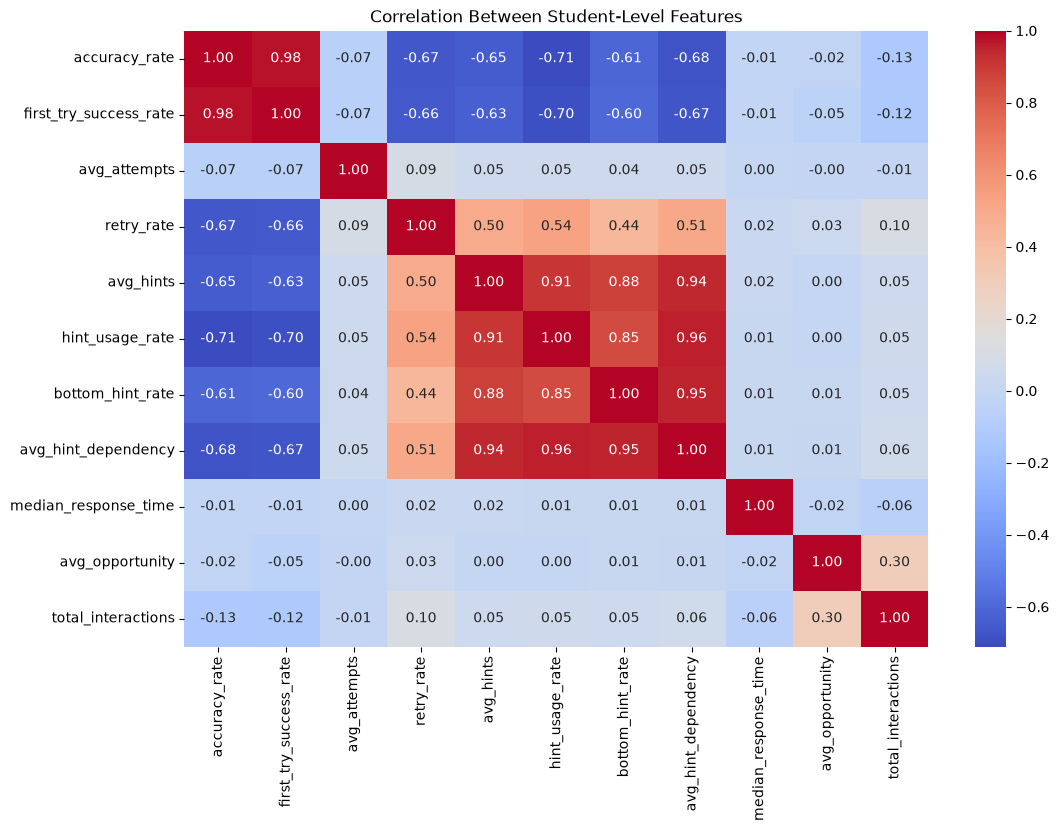

In [32]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    student_skill_df.drop(columns=['user_id', 'skill_id_clean']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Student-Level Features')
plt.show()

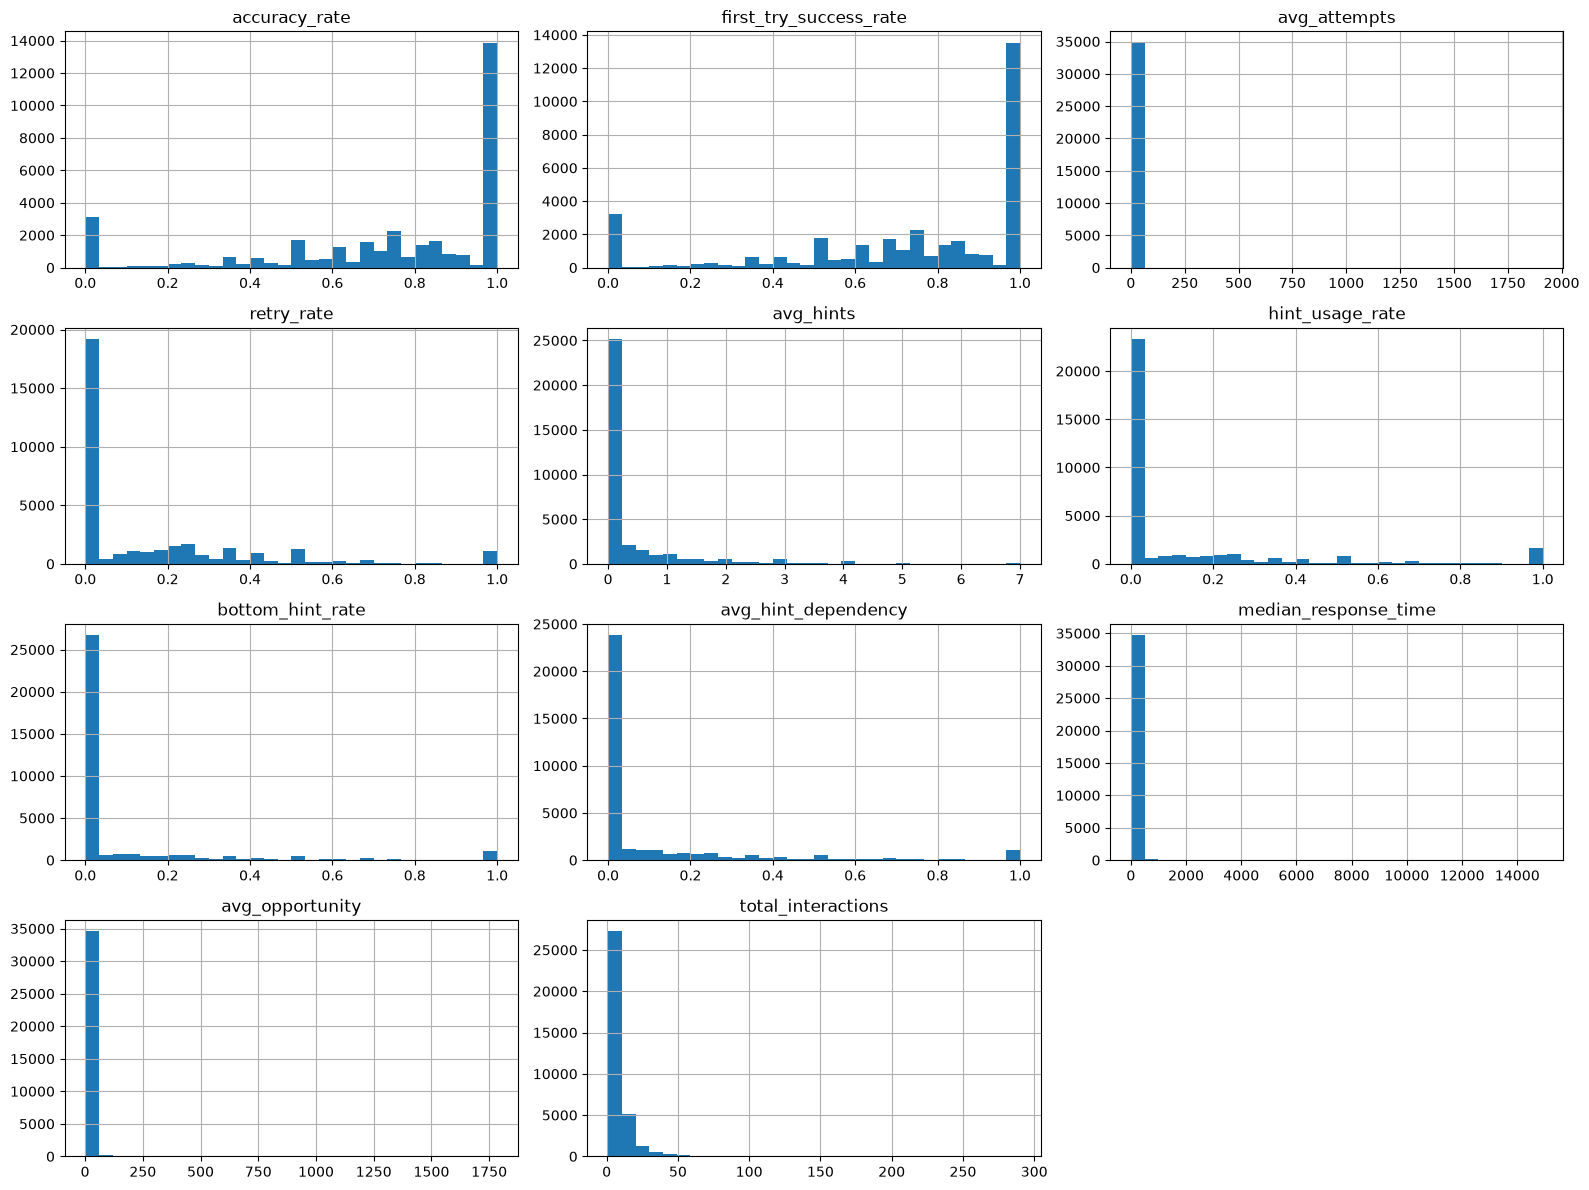

In [33]:
features = [
    'accuracy_rate',
    'first_try_success_rate',
    'avg_attempts',
    'retry_rate',
    'avg_hints',
    'hint_usage_rate',
    'bottom_hint_rate',
    'avg_hint_dependency',
    'median_response_time',
    'avg_opportunity',
    'total_interactions',
]

student_skill_df[features].hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

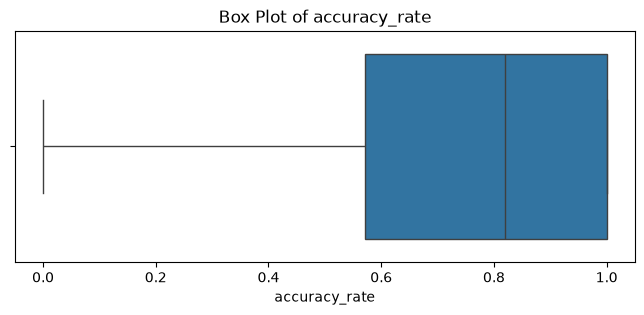

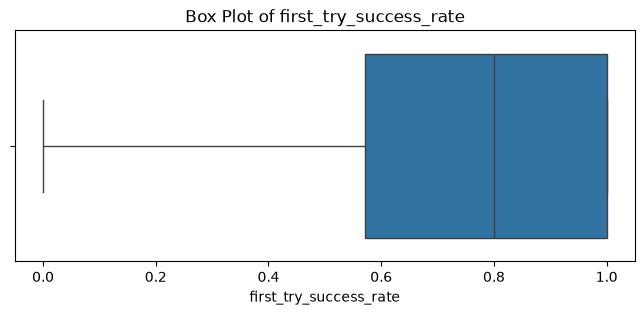

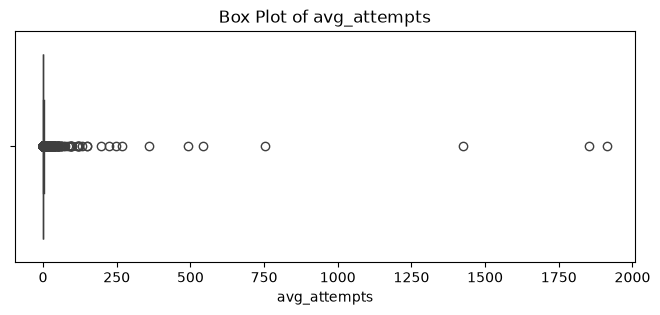

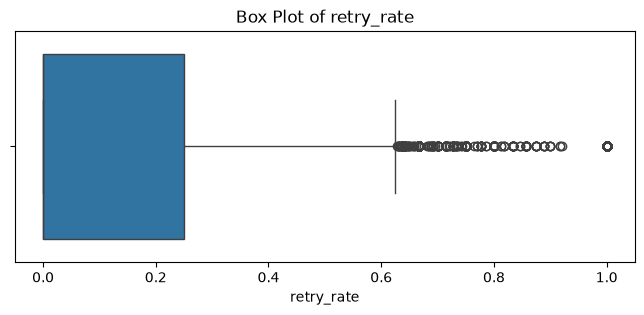

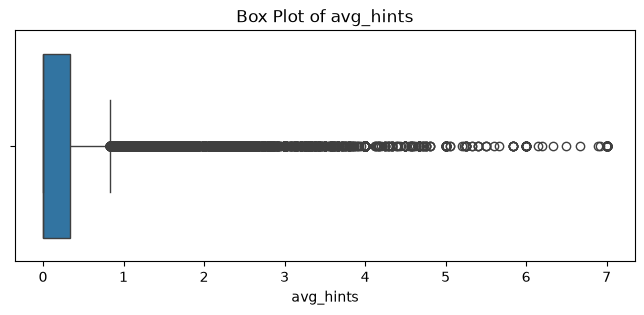

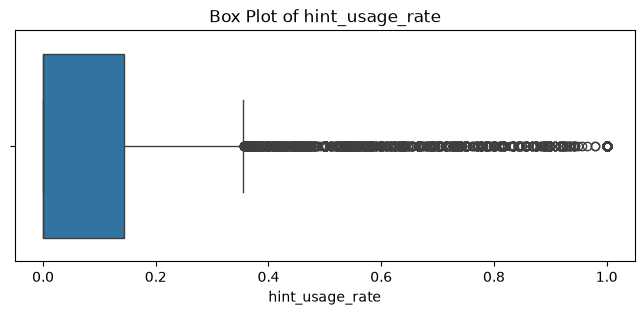

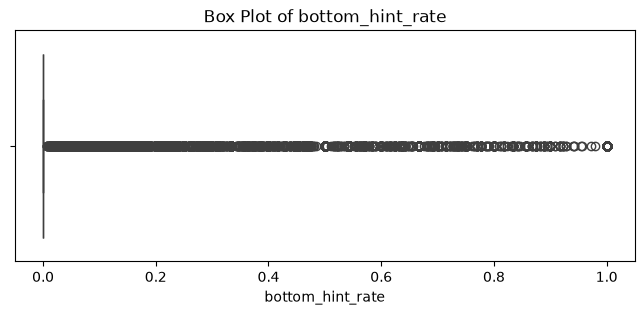

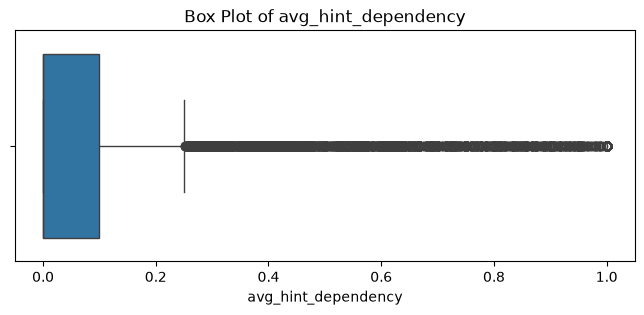

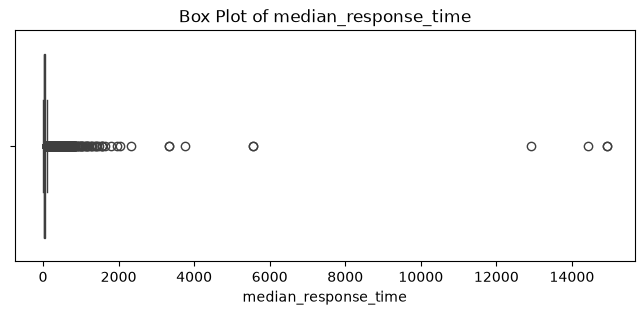

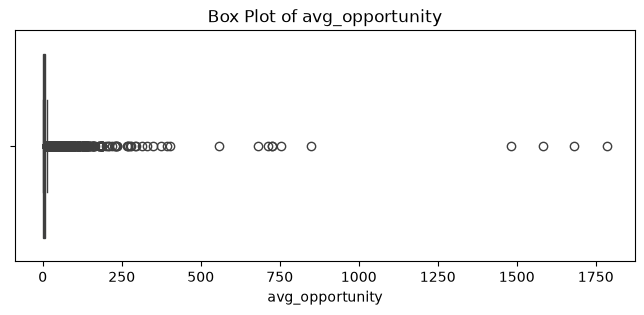

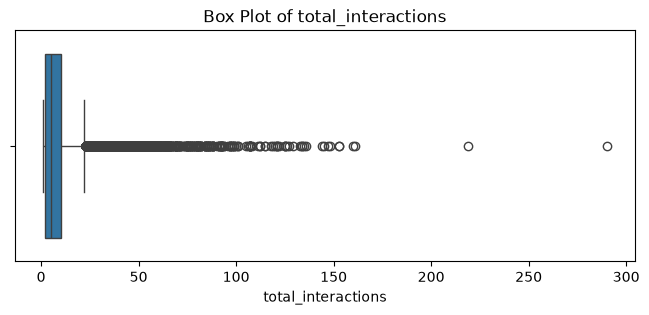

In [34]:
for col in features:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=student_skill_df[col]
    )

    plt.title(f'Box Plot of {col}')
    plt.show()

In [35]:
for col in features:
    Q1 = student_skill_df[col].quantile(0.25)
    Q3 = student_skill_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = student_skill_df[
        (student_skill_df[col] < lower) |
        (student_skill_df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

accuracy_rate: 0 outliers
first_try_success_rate: 0 outliers
avg_attempts: 4653 outliers
retry_rate: 1863 outliers
avg_hints: 5370 outliers
hint_usage_rate: 4677 outliers
bottom_hint_rate: 8313 outliers
avg_hint_dependency: 4949 outliers
median_response_time: 2940 outliers
avg_opportunity: 2774 outliers
total_interactions: 2091 outliers


In [36]:
features = [
    'accuracy_rate',
    'first_try_success_rate',
    'avg_attempts',
    'retry_rate',
    'avg_hints',
    'hint_usage_rate',
    'bottom_hint_rate',
    'median_response_time',
    'avg_opportunity',
    'total_interactions',
]

X = student_skill_df[features]

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

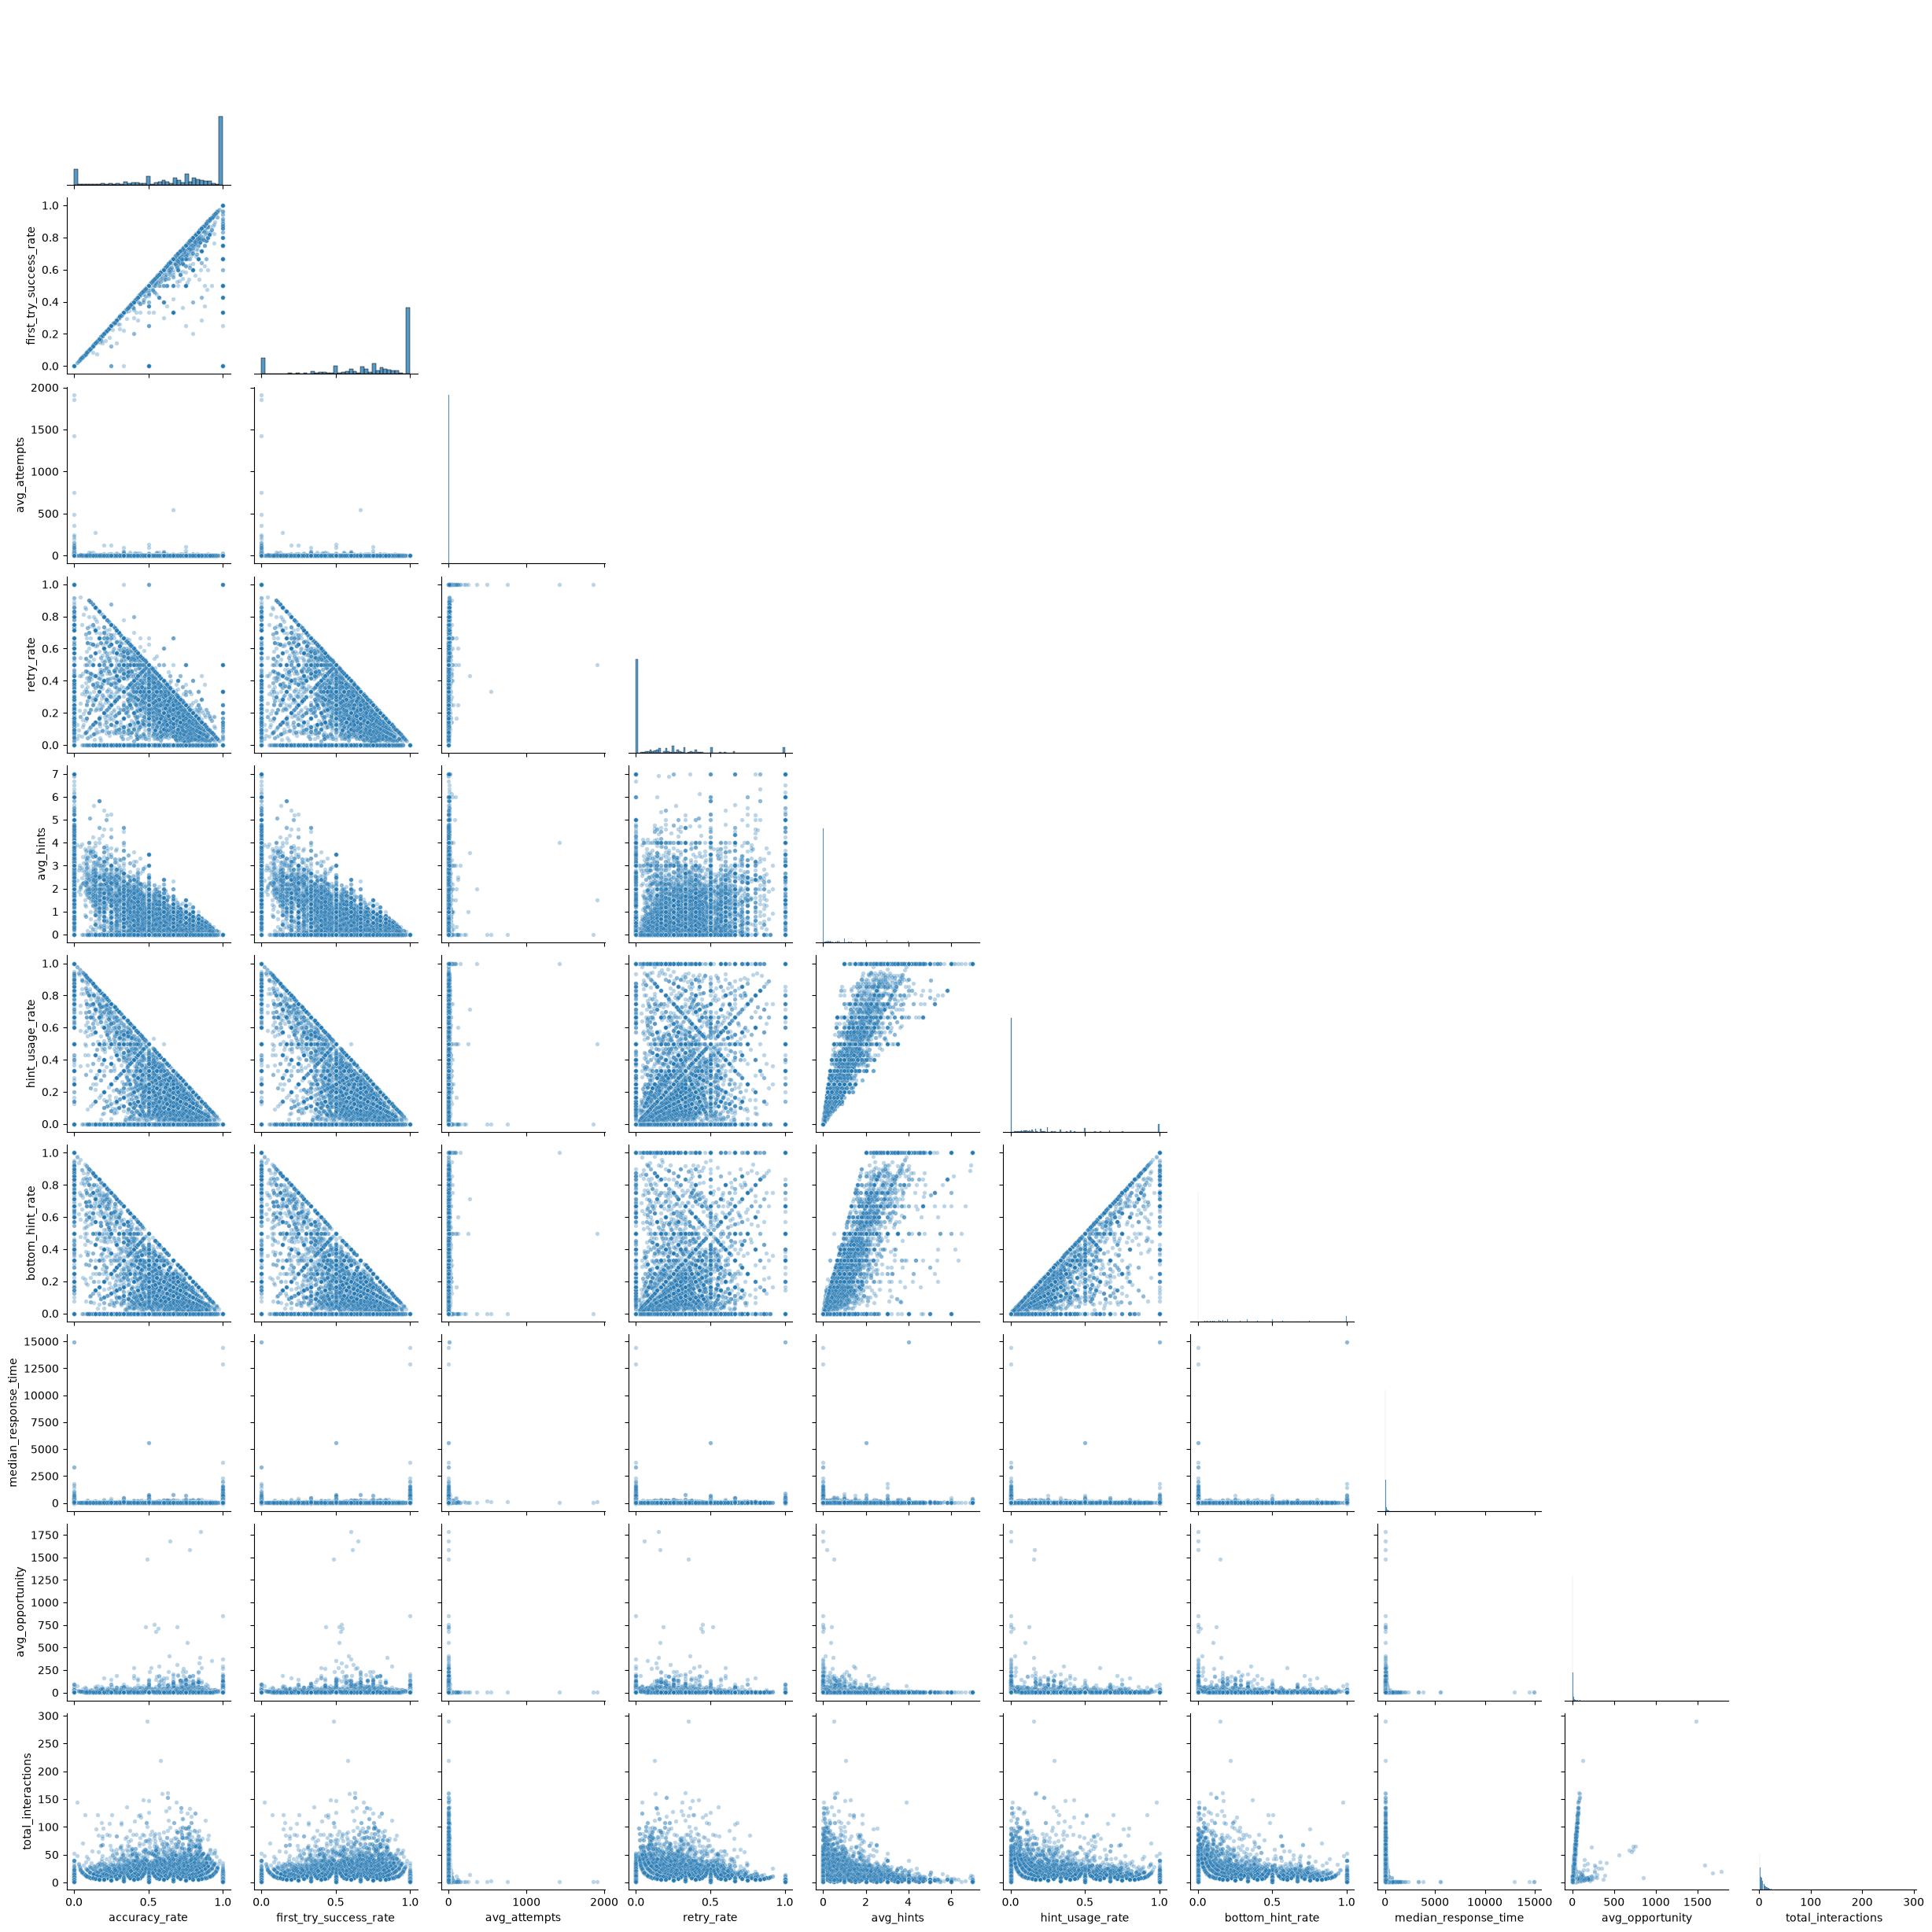

In [37]:
# Features that will potentially be used for clustering
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

sns.pairplot(
    X,
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.3, 's': 15}
)

plt.show()

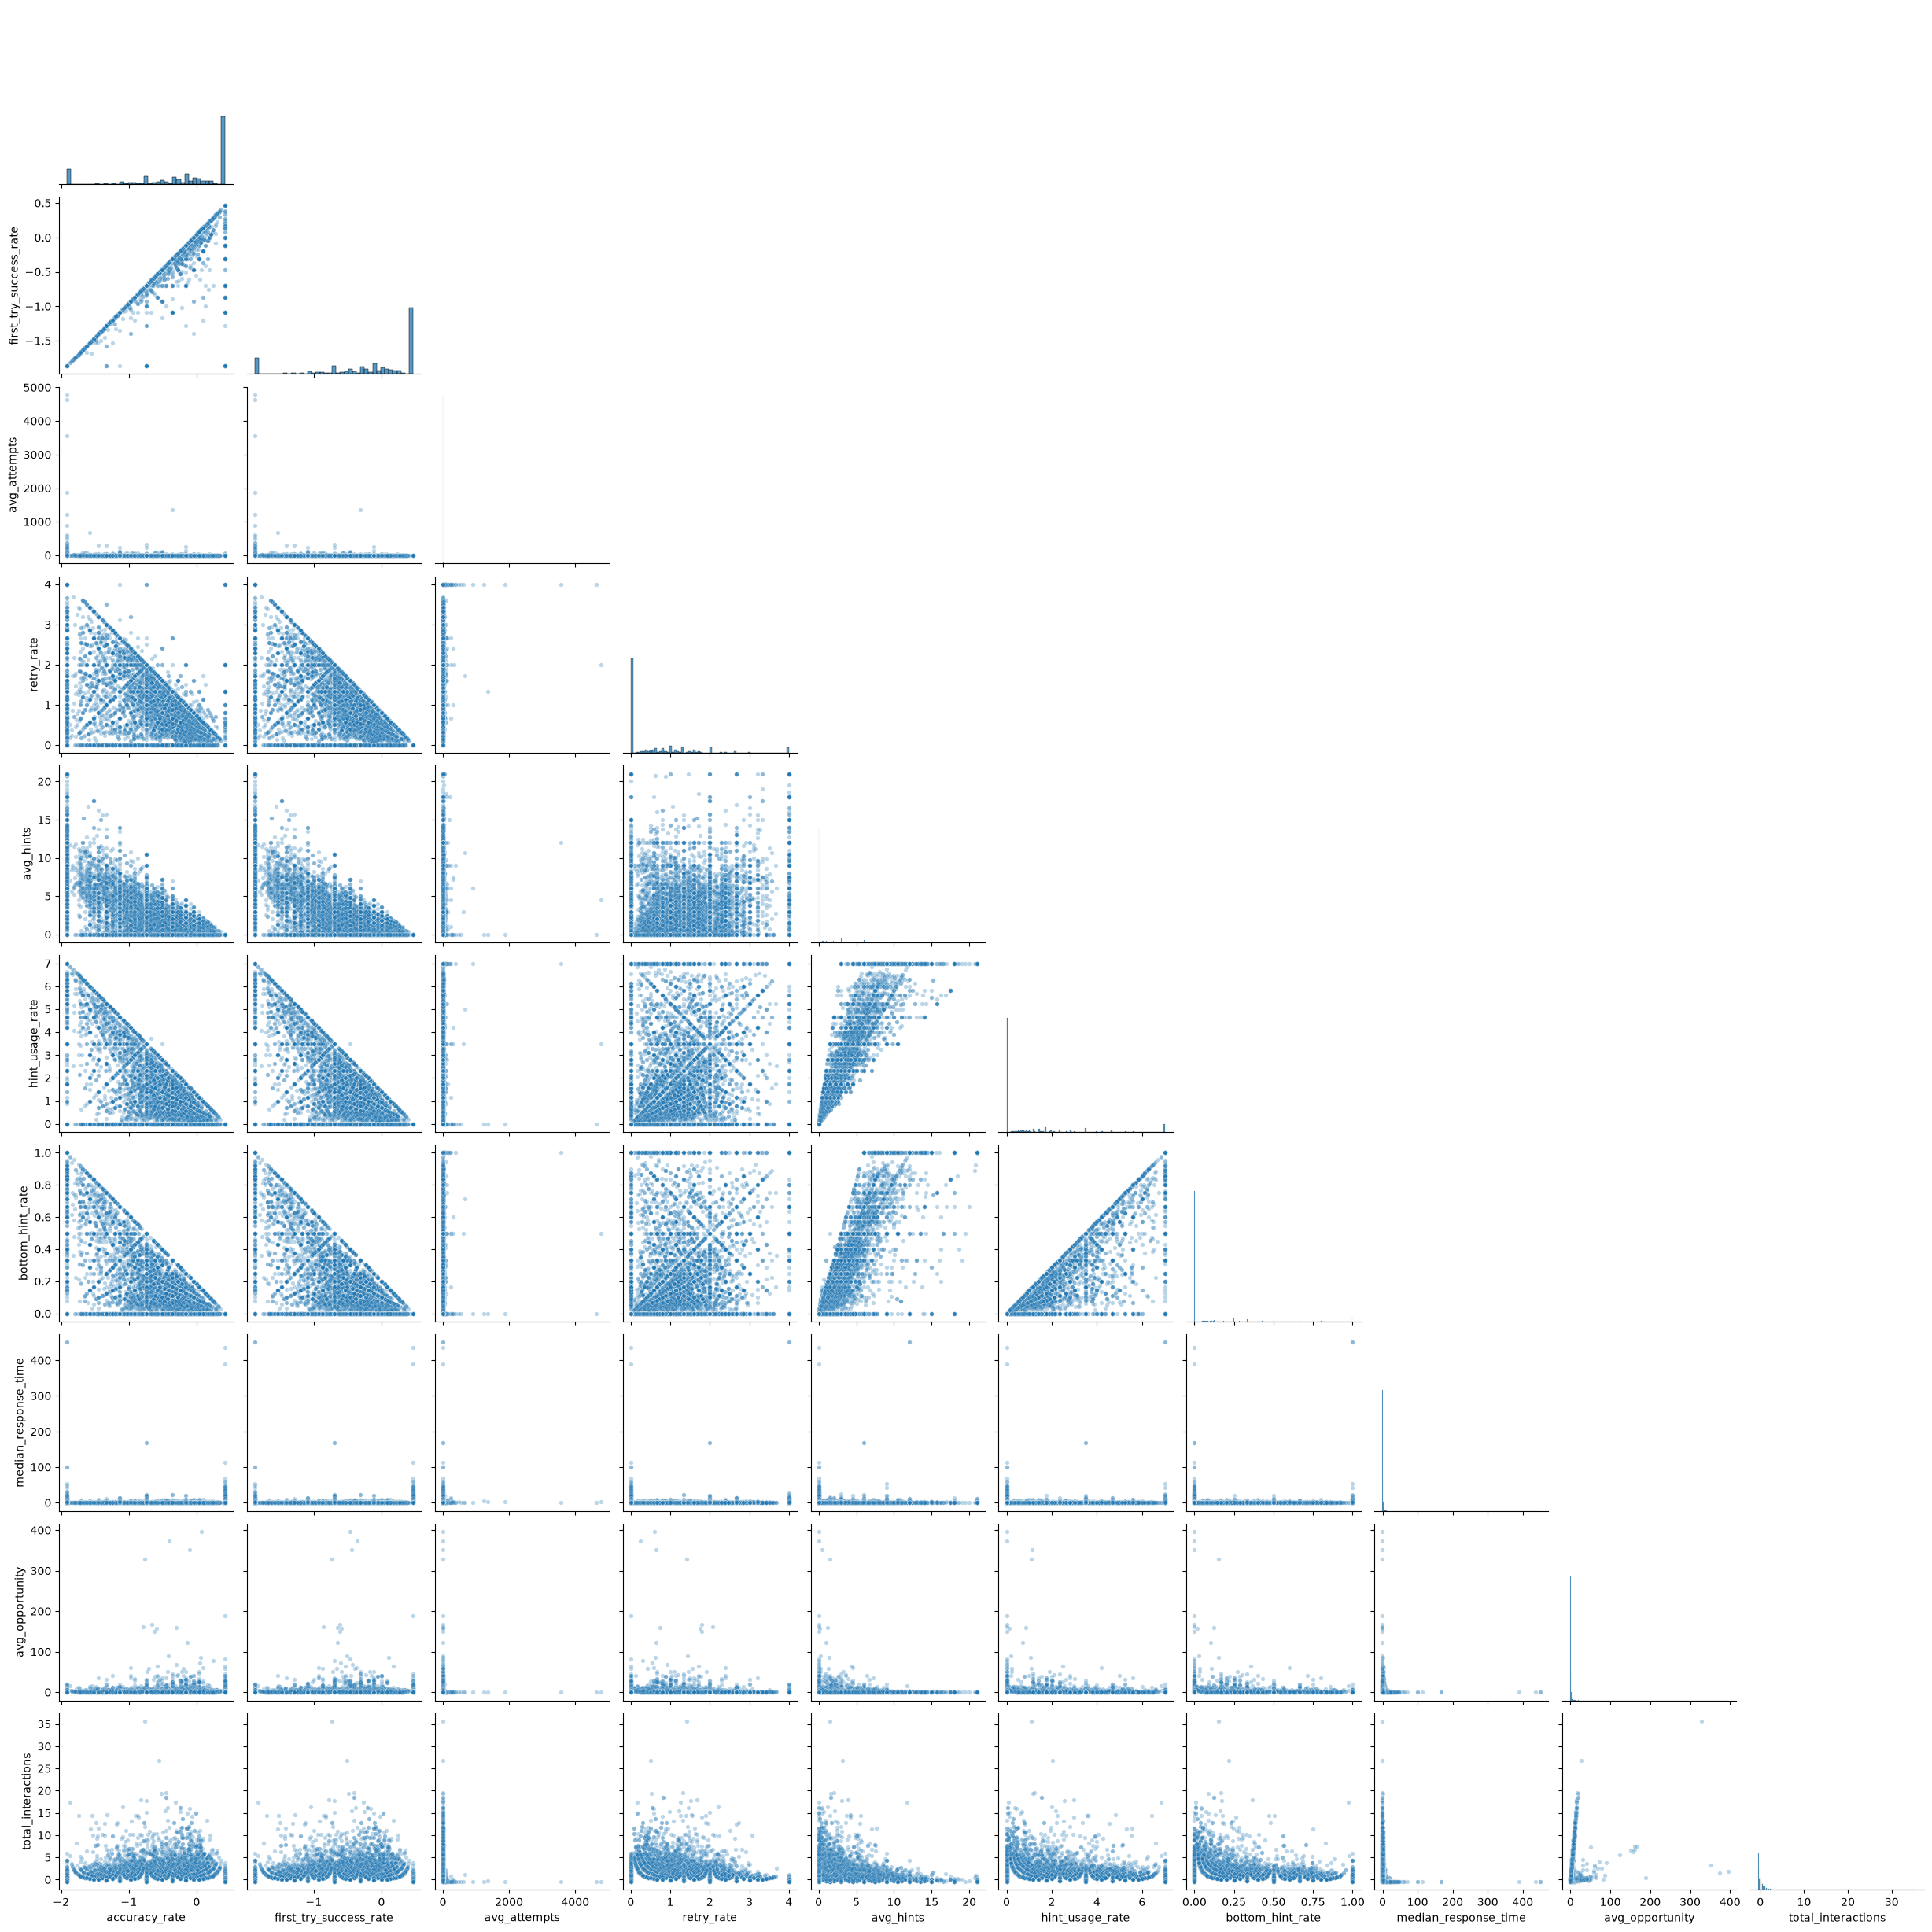

In [38]:
# Features that will potentially be used for clustering
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

sns.pairplot(
    X_scaled_df,
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.3, 's': 15}
)

plt.show()

# Modelling Approach
What are the models you are planning to build for your capstone.
- **You only need to outline your approach here. No need to execute**

The project will use **unsupervised clustering models** to identify groups of similar student-skill performance and learning behavior profiles.

* **K-Means Clustering:** The primary model. The optimal number of clusters will be evaluated using the **Elbow Method** and **Silhouette Score**.
* **Hierarchical Clustering:** A comparison model to examine the hierarchical structure and similarity between student performance profiles.
* **DBSCAN:** An alternative density-based model that can identify dense groups as well as unusual observations or noise.